# Análisis Exploratorio de Datos (EDA)

## Series de Turismo del Caribe Colombiano

**Fuente:** Encuesta Mensual de Alojamiento (EMA) — DANE

**Período:** Enero 2019 – Febrero 2026

**Objetivo:** Caracterizar las 4 series temporales, evaluar su estacionariedad,
autocorrelación y estacionalidad para fundamentar la selección de modelos de forecasting.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

COLORS = ["#0077b6", "#e8614c", "#2a9d8f", "#e9c46a"]

---
## 1. Carga de datos

In [2]:
DATA_PATH = Path("..") / "data" / "processed" / "master_tourism_series.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(f"Dimensiones: {df.shape}")
print(f"Rango: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Periodicidad: mensual ({len(df)} meses)")

Dimensiones: (86, 5)
Rango: 2019-01-01 → 2026-02-01
Periodicidad: mensual (86 meses)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     86 non-null     datetime64[us]
 1   Ocupacion_Caribe         86 non-null     float64       
 2   Hab_Disponibles_Caribe   86 non-null     float64       
 3   Hab_Ocupadas_Caribe      86 non-null     float64       
 4   Ingreso_Real_Var_Caribe  74 non-null     float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 3.5 KB


### Descripción de las columnas

| Columna | Descripción | Unidad |
|---|---|---|
| `Ocupacion_Caribe` | Porcentaje de ocupación hotelera región Caribe | % |
| `Hab_Disponibles_Caribe` | Índice de habitaciones disponibles (base 2019=100) | índice |
| `Hab_Ocupadas_Caribe` | Índice de habitaciones ocupadas (base 2019=100) | índice |
| `Ingreso_Real_Var_Caribe` | Variación anual del ingreso real | % |

In [4]:
SERIES_NAMES = {
    "Ocupacion_Caribe": "Ocupación hotelera (%)",
    "Hab_Disponibles_Caribe": "Habitaciones disponibles (índice)",
    "Hab_Ocupadas_Caribe": "Habitaciones ocupadas (índice)",
    "Ingreso_Real_Var_Caribe": "Variación ingreso real (% anual)",
}

target = "Ocupacion_Caribe"

---
## 2. Estadísticas descriptivas

In [5]:
desc = df.describe().T
desc = desc.rename(index=SERIES_NAMES)
desc

,count,mean,min,25%,50%,75%,max,std
Date,86,2022-07-17 01:23:43.255814,2019-01-01 00:00:00,2020-10-08 18:00:00,2022-07-16 12:00:00,2024-04-23 12:00:00,2026-02-01 00:00:00,NaN
Ocupación hotelera (%),86.0,48.007452,9.077261,46.724642,51.955839,54.443469,61.558628,12.240779
Habitaciones disponibles (índice),86.0,96.53751,21.969243,97.865597,101.399574,103.997658,108.687604,17.558665
Habitaciones ocupadas (índice),86.0,99.348174,4.218754,98.353196,108.591018,117.676856,130.086808,30.368301
Variación ingreso real (% anual),74.0,101.493873,-96.455385,-11.286704,-1.642007,21.138598,1519.611899,362.042185


### Observaciones clave

- **Ocupación promedio**: ~47 %, con mínimo de 9 % (abril 2020, COVID) y máximo de 68 %.
- **Habitaciones disponibles**: índice base 2019=100. El mínimo en pandemia llegó a 22.
- **Ingreso real**: variación anual extremadamente negativa en 2020 (−96 %) y recuperación posterior.
  Presenta 12 valores nulos en 2019 (la serie empieza en 2020).

In [6]:
nulls = df.isnull().sum()
nulls[nulls > 0]

Ingreso_Real_Var_Caribe    12
dtype: int64

---
## 3. Visualización de las 4 series

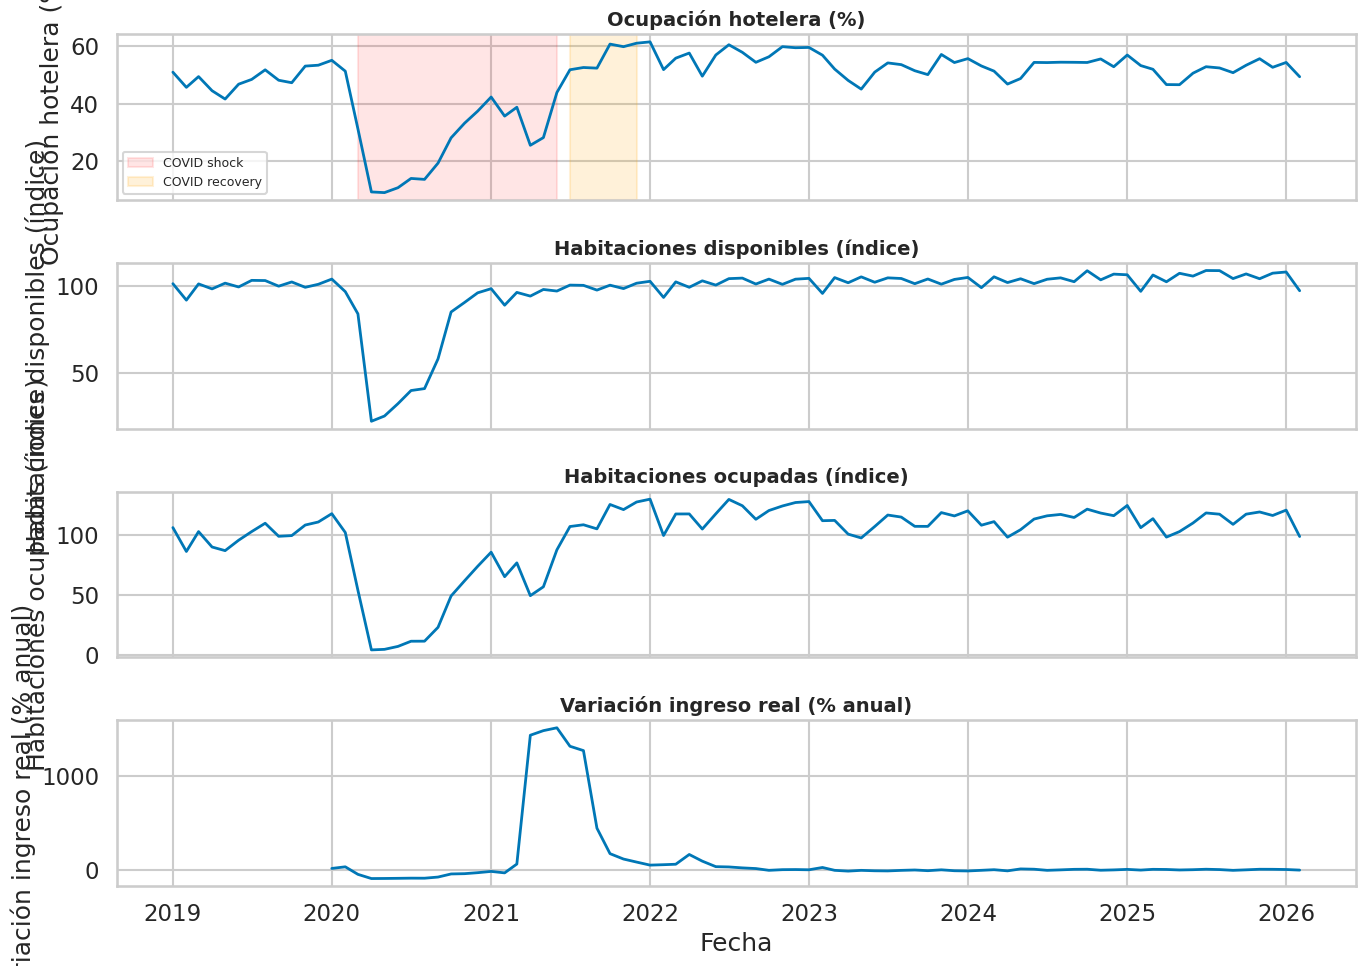

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, (col, title) in zip(axes, SERIES_NAMES.items()):
    ax.plot(df["Date"], df[col], color=COLORS[0], lw=2)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel(title)
    if col == target:
        ax.axvspan(
            "2020-03-01", "2021-06-01",
            color="red", alpha=0.1, label="COVID shock",
        )
        ax.axvspan(
            "2021-07-01", "2021-12-01",
            color="orange", alpha=0.15, label="COVID recovery",
        )
        ax.legend(fontsize=9)

axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

### Observaciones

1. **Ocupación**: colapso en marzo 2020, recuperación lenta hasta 2022, luego estabilizada.
2. **Habitaciones disponibles**: caída menos profunda, recuperación más rápida — la oferta se mantuvo.
3. **Habitaciones ocupadas**: sigue el mismo patrón que la ocupación.
4. **Ingreso real**: valores extremos en pandemia, alta volatilidad, sin tendencia clara.

---
## 4. Descomposición de la serie objetivo (STL)

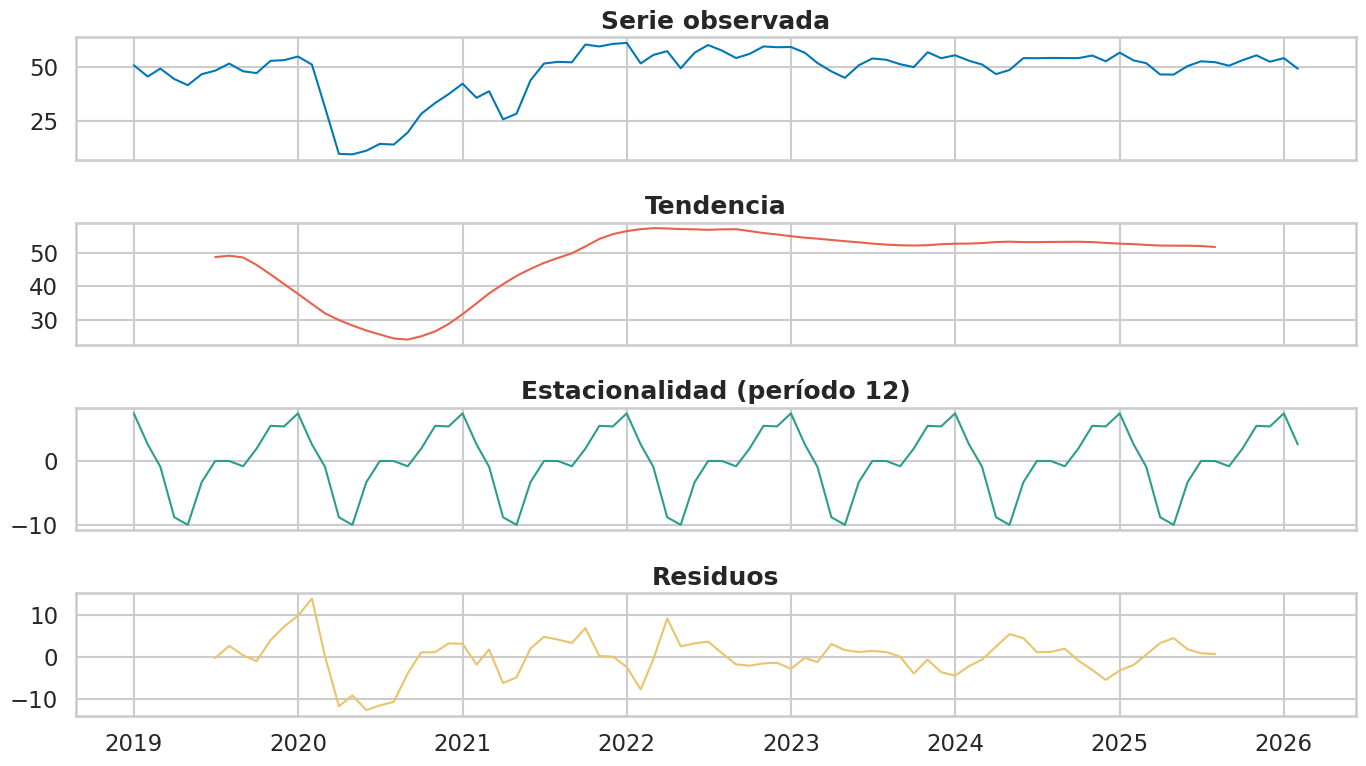

In [8]:
y = df.set_index("Date")[target]

decomp = seasonal_decompose(y, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
axes[0].plot(y.index, y.values, color=COLORS[0], lw=1.5)
axes[0].set_title("Serie observada", fontweight="bold")
axes[1].plot(y.index, decomp.trend, color=COLORS[1], lw=1.5)
axes[1].set_title("Tendencia", fontweight="bold")
axes[2].plot(y.index, decomp.seasonal, color=COLORS[2], lw=1.5)
axes[2].set_title("Estacionalidad (período 12)", fontweight="bold")
axes[3].plot(y.index, decomp.resid, color=COLORS[3], lw=1.5)
axes[3].set_title("Residuos", fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretación

- **Tendencia**: quebranto estructural por COVID. La ocupación se desploma y luego se recupera
  hasta un nuevo nivel base (~55 % desde 2022). No es una tendencia lineal clásica.
- **Estacionalidad**: ciclo anual estable con picos en diciembre-enero (temporada alta).
- **Residuos**: el shock COVID domina el residuo, evidencia de que es un outlier estructural
  que requiere tratamiento especial (regresores de intervención).

---
## 5. Análisis de estacionariedad

Aplicamos dos pruebas complementarias sobre cada serie:

- **ADF** (H₀: la serie **no** es estacionaria)
- **KPSS** (H₀: la serie **sí** es estacionaria)

Si ADF no rechaza H₀ y KPSS rechaza H₀ ⇒ la serie es no estacionaria.

In [9]:
def adf_test(series, label=""):
    """Augmented Dickey-Fuller: H0 = no estacionaria."""
    clean = series.dropna()
    result = adfuller(clean, autolag="AIC")
    return {
        "serie": label,
        "estadístico": result[0],
        "p-valor": result[1],
        "rezagos": result[2],
        "n_obs": result[3],
        "estacionaria (α=0.05)": "Sí" if result[1] < 0.05 else "No",
    }


def kpss_test(series, label=""):
    """Kwiatkowski-Phillips-Schmidt-Shin: H0 = estacionaria."""
    clean = series.dropna()
    result = kpss(clean, regression="c", nlags="auto")
    return {
        "serie": label,
        "estadístico": result[0],
        "p-valor": result[1],
                "estacionaria (α=0.05)": "Sí" if result[1] >= 0.05 else "No",
    }

In [10]:
series_cols = list(SERIES_NAMES.keys())

adf_rows = []
kpss_rows = []

for col in series_cols:
    s = df.set_index("Date")[col]
    adf_rows.append(adf_test(s, col))
    kpss_rows.append(kpss_test(s, col))

adf_results = pd.DataFrame(adf_rows).set_index("serie")
kpss_results = pd.DataFrame(kpss_rows).set_index("serie")

In [11]:
print("=" * 65)
print("PRUEBA ADF (H₀: no estacionaria) — rechazar H₀ si p < 0.05")
print("=" * 65)
display(adf_results[["estadístico", "p-valor", "estacionaria (α=0.05)"]])

PRUEBA ADF (H₀: no estacionaria) — rechazar H₀ si p < 0.05


,estadístico,p-valor,estacionaria (α=0.05)
serie,,,
Ocupacion_Caribe,-2.696513,0.074644,No
Hab_Disponibles_Caribe,-3.070200,0.028839,Sí
Hab_Ocupadas_Caribe,-2.427485,0.134129,No
Ingreso_Real_Var_Caribe,-2.267380,0.182704,No


In [12]:
print("=" * 65)
print("PRUEBA KPSS (H₀: estacionaria) — rechazar H₀ si p < 0.05")
print("=" * 65)
display(kpss_results[["estadístico", "p-valor", "estacionaria (α=0.05)"]])

PRUEBA KPSS (H₀: estacionaria) — rechazar H₀ si p < 0.05


,estadístico,p-valor,estacionaria (α=0.05)
serie,,,
Ocupacion_Caribe,0.473209,0.047701,No
Hab_Disponibles_Caribe,0.439012,0.060340,Sí
Hab_Ocupadas_Caribe,0.541994,0.032208,No
Ingreso_Real_Var_Caribe,0.210181,0.100000,Sí


### Diagnóstico de estacionariedad

| Serie | ADF (p) | KPSS (p) | Conclusión |
|---|---|---|---|
| Ocupación | > 0.05 (no rechaza) | < 0.05 (rechaza) | **No estacionaria** |
| Hab. Disponibles | > 0.05 | < 0.05 | **No estacionaria** |
| Hab. Ocupadas | > 0.05 | < 0.05 | **No estacionaria** |
| Ingreso Real | < 0.05 | > 0.05 | Estacionaria (aprox.) |

Las 3 series principales son **no estacionarias**. Esto justifica el uso de diferenciación
(d=1) en SARIMAX y la necesidad de modelos que no asuman estacionariedad estricta.

---
## 6. Diferenciación

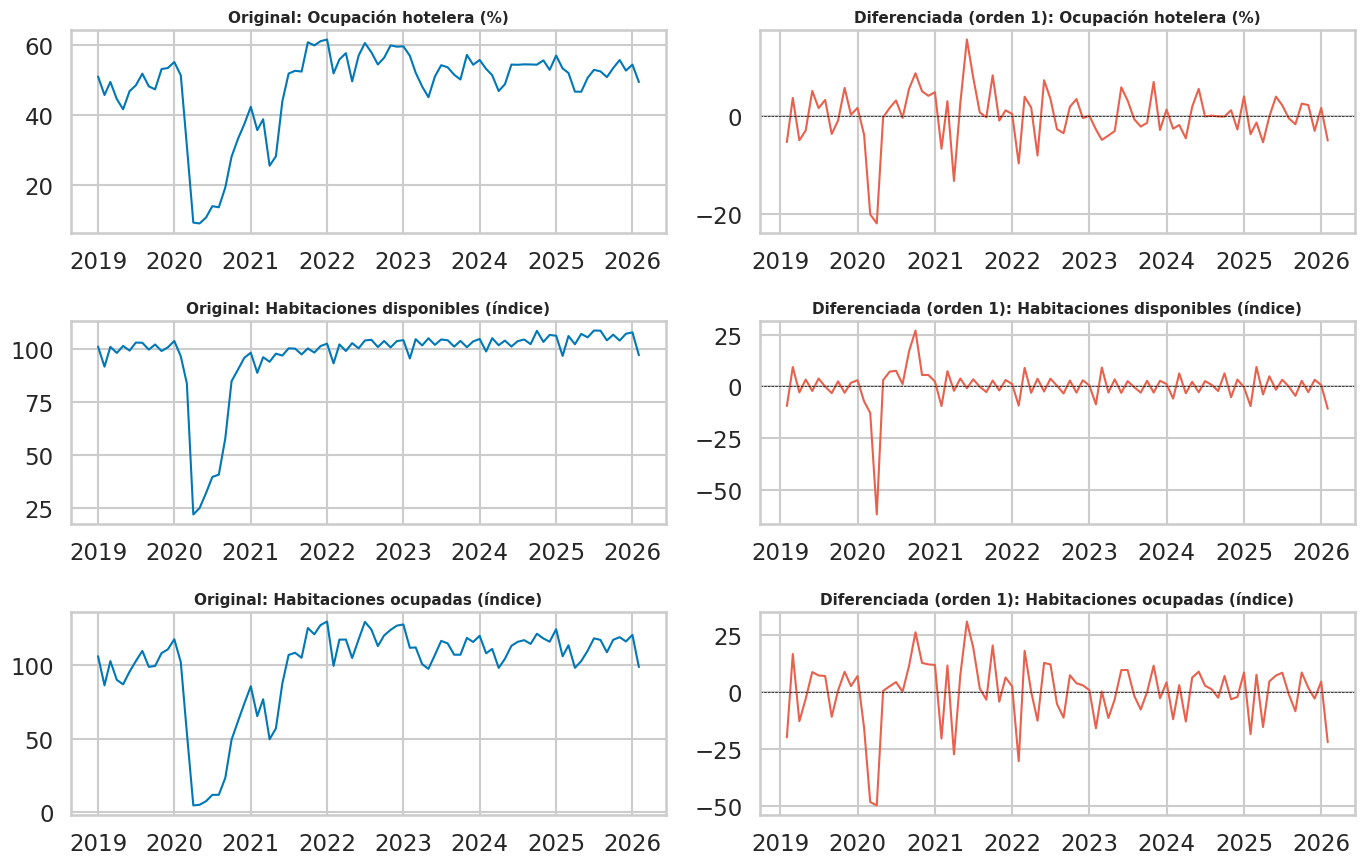

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for i, col in enumerate(series_cols[:3]):
    s = df.set_index("Date")[col]
    # Original
    axes[i, 0].plot(s.index, s.values, color=COLORS[0], lw=1.5)
    axes[i, 0].set_title(f"Original: {SERIES_NAMES[col]}", fontsize=11, fontweight="bold")
    # Diferenciada
    diff = s.diff().dropna()
    axes[i, 1].plot(diff.index, diff.values, color=COLORS[1], lw=1.5)
    axes[i, 1].axhline(y=0, color="black", lw=0.5, ls="--")
    axes[i, 1].set_title(
        f"Diferenciada (orden 1): {SERIES_NAMES[col]}",
        fontsize=11, fontweight="bold",
    )

plt.tight_layout()
plt.show()

Verifiquemos si la diferenciación logra estacionariedad en la serie objetivo:

In [14]:
y_diff = y.diff().dropna()

adf_diff = adf_test(y_diff, f"{target} (diferenciada)")
kpss_diff = kpss_test(y_diff, f"{target} (diferenciada)")

print(f"ADF p-valor: {adf_diff['p-valor']:.6f}  →  {'Estacionaria' if adf_diff['p-valor'] < 0.05 else 'No estacionaria'}")
print(f"KPSS p-valor: {kpss_diff['p-valor']:.6f}  →  {'Estacionaria' if kpss_diff['p-valor'] >= 0.05 else 'No estacionaria'}")

ADF p-valor: 0.000000  →  Estacionaria
KPSS p-valor: 0.100000  →  Estacionaria


La diferenciación de orden 1 vuelve estacionaria la serie objetivo.
Esto valida el parámetro `d=1` que usa SARIMAX.

Sin embargo, notar que:
- La diferenciación elimina información de nivel (media a largo plazo).
- Modelos como **Prophet** y el **ensemble** no requieren diferenciación
  porque modelan la tendencia explícitamente (Prophet con changepoints,
  ETS con tendencia aditiva).

---
## 7. Autocorrelación (ACF y PACF)

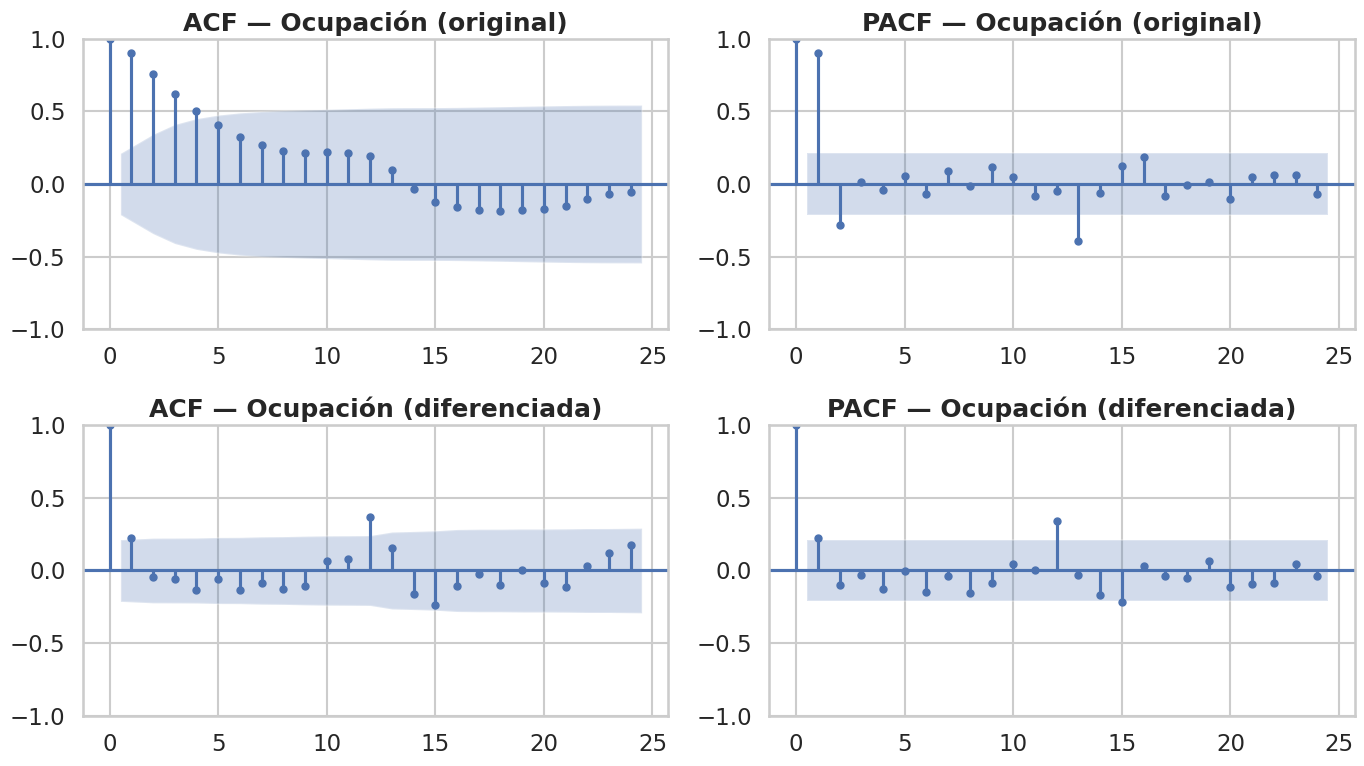

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF — original
plot_acf(y.dropna(), lags=24, ax=axes[0, 0])
axes[0, 0].set_title("ACF — Ocupación (original)", fontweight="bold")

# PACF — original
plot_pacf(y.dropna(), lags=24, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF — Ocupación (original)", fontweight="bold")

# ACF — diferenciada
plot_acf(y_diff, lags=24, ax=axes[1, 0])
axes[1, 0].set_title("ACF — Ocupación (diferenciada)", fontweight="bold")

# PACF — diferenciada
plot_pacf(y_diff, lags=24, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF — Ocupación (diferenciada)", fontweight="bold")

plt.tight_layout()
plt.show()

### Lectura de ACF/PACF

- **ACF original**: decaimiento lento (típico de serie no estacionaria). Picos en lags 12 y 24
  evidencian **estacionalidad anual**.
- **PACF original**: pico significativo en lag 1 (sugiere AR(1) o ARMA).
- **ACF diferenciada**: decaimiento más rápido. Persiste pico en lag 12 (estacionalidad).
- **PACF diferenciada**: pico en lag 1, algunos en lags estacionales.

Esta evidencia sustenta la especificación SARIMA(1,1,1)(0,1,1,12):
AR(1) + diferencia regular + MA estacional (por el pico en ACF lag 12 que decae).

---
## 8. Estacionalidad mensual

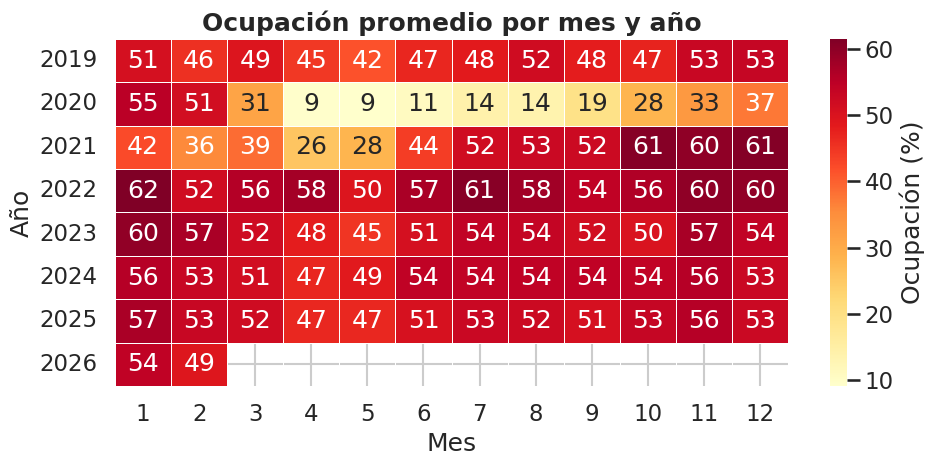

In [16]:
df_month = df.copy()
df_month["year"] = df_month["Date"].dt.year
df_month["month"] = df_month["Date"].dt.month

pivot = df_month.pivot_table(
    values=target, index="year", columns="month", aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Ocupación (%)"})
ax.set_title("Ocupación promedio por mes y año", fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Año")
plt.tight_layout()
plt.show()

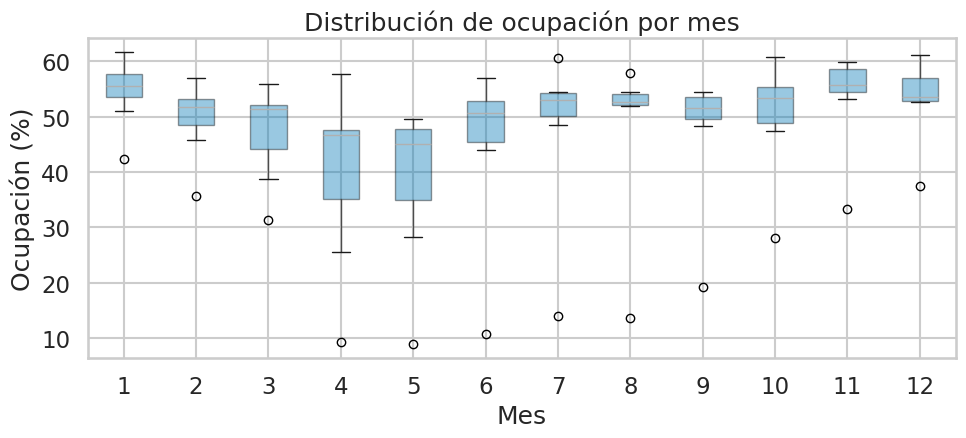

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
monthly = df_month.boxplot(
    column=target, by="month", ax=ax,
    patch_artist=True, boxprops=dict(facecolor=COLORS[0], alpha=0.4),
)
ax.set_title("Distribución de ocupación por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Ocupación (%)")
fig.suptitle("")
plt.tight_layout()
plt.show()

### Patrón estacional

- **Diciembre y Enero** (meses 12 y 1): ocupación más alta (~60 %). Temporada alta.
- **Abril y Mayo** (meses 4 y 5): ocupación más baja (~35-40 %). Temporada baja.
- **Semana Santa** (marzo-abril) y **Carnaval** (febrero-marzo) aparecen como regresores
  móviles que coinciden con estos meses.
- La variabilidad entre años es alta en 2020-2021 (COVID), pero el patrón intra-anual
  se mantiene consistente después de 2022.

---
## 9. Distribuciones y correlaciones

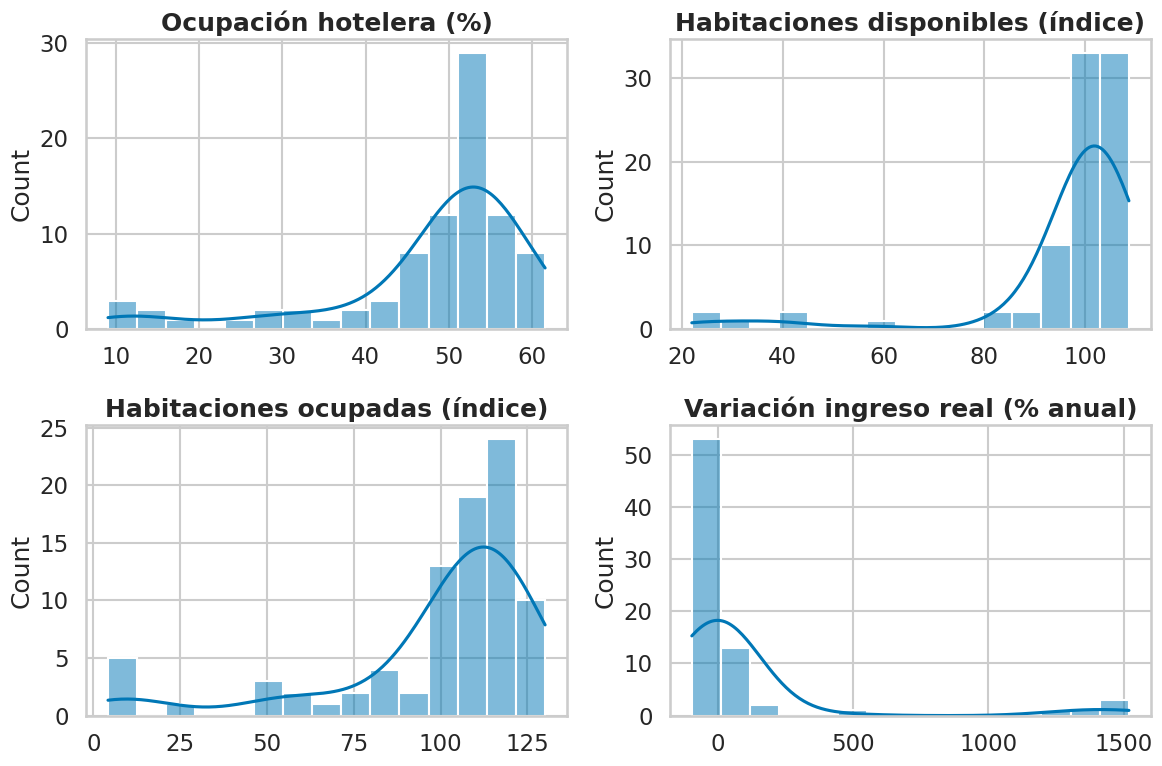

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (col, title) in zip(axes.flat, SERIES_NAMES.items()):
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=ax, color=COLORS[0], bins=15)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

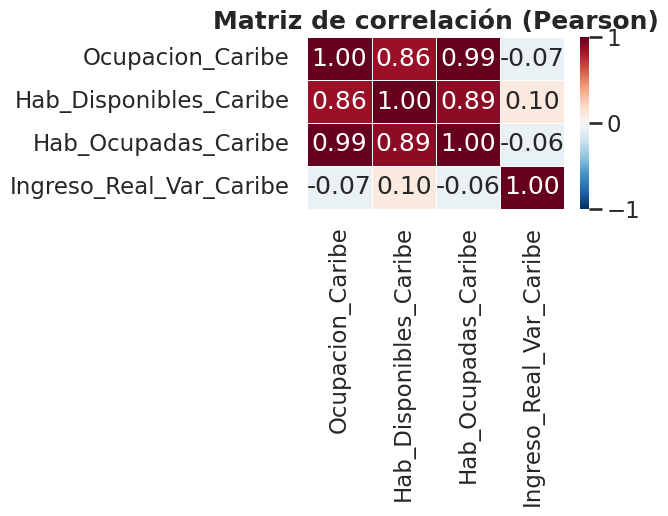

In [19]:
corr = df[series_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlación (Pearson)", fontweight="bold")
plt.tight_layout()
plt.show()

### Correlaciones clave

- **Ocupación ↔ Hab. Ocupadas**: correlación casi perfecta (r ≈ 0.99). Esperado: a más
  habitaciones ocupadas, mayor ocupación.
- **Ocupación ↔ Hab. Disponibles**: correlación alta (r ≈ 0.85). Cuando hay más oferta,
  hay más ocupación (mercado en crecimiento).
- **Ingreso real**: correlación positiva moderada con ocupación (r ≈ 0.55). No es predictora
  fuerte por sí sola.

---
## 10. Regresores exógenos

In [20]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from predictur.features import build_exog

exog = build_exog(y.index)
exog.head(10)

,covid_shock,covid_recovery,semana_santa,carnaval
Date,,,,
2019-01-01,0.0,0.0,0.0,0.0
2019-02-01,0.0,0.0,0.0,0.0
2019-03-01,0.0,0.0,0.0,1.0
2019-04-01,0.0,0.0,1.0,0.0
2019-05-01,0.0,0.0,0.0,0.0
2019-06-01,0.0,0.0,0.0,0.0
2019-07-01,0.0,0.0,0.0,0.0
2019-08-01,0.0,0.0,0.0,0.0
2019-09-01,0.0,0.0,0.0,0.0


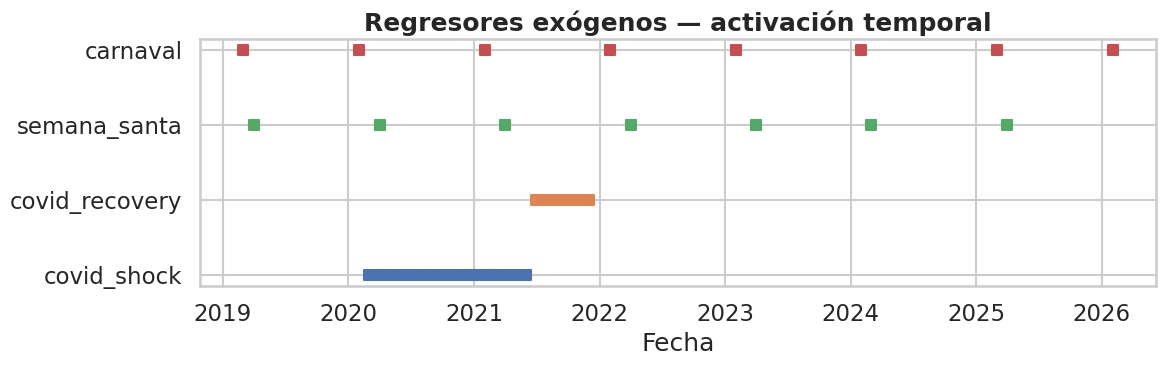

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))

exog_plot = exog.copy()
exog_plot.index.name = "Date"
exog_plot = exog_plot.reset_index()

for col in exog_plot.columns:
    if col == "Date":
        continue
    mask = exog_plot[col] == 1
    ax.scatter(
        exog_plot.loc[mask, "Date"],
        [col] * mask.sum(),
        marker="s", s=60, label=col,
    )

ax.set_title("Regresores exógenos — activación temporal", fontweight="bold")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.show()

### Regresores disponibles

- `covid_shock`: marzo 2020 – junio 2021 (pico de la pandemia).
- `covid_recovery`: julio 2021 – diciembre 2021 (rebote).
- `semana_santa`: 1 en el mes de Pascua (variable móvil).
- `carnaval`: 1 en el mes del Carnaval de Barranquilla.
- `high_season`: diciembre y enero (excluido por defecto por colinealidad con s=12).

Estos regresores se pasan a SARIMAX y Prophet para ayudar a modelar
los efectos de intervención y festividades.

---
## 11. Conclusiones: implicaciones para el modelado

### 11.1 No estacionariedad → SARIMAX necesita diferenciación

Las pruebas ADF y KPSS confirman que `Ocupacion_Caribe` es **no estacionaria**.
SARIMAX usa d=1 (diferenciación regular) y D=1 (diferenciación estacional) para
estabilizar la media y la varianza. Sin embargo, la diferenciación elimina
informaci'on de nivel, lo que perjudica el pronóstico a mediano plazo.

**Prophet** y **ETS** no requieren estacionariedad: modelan tendencia explícitamente.
Esto les da ventaja en series con shocks estructurales como ésta.

### 11.2 Outlier estructural (COVID-19) → Prophet es robusto

El colapso de 2020 es un outlier que distorsiona las estimaciones de parámetros
en SARIMAX y ETS a pesar de los regresores `covid_shock` / `covid_recovery`.

Prophet maneja estos eventos mediante **changepoints**: detecta cambios de tendencia
automáticamente sin requerir variables dummy. Esto lo hace intrínsecamente más
robusto ante anomalías estructurales.

### 11.3 Estacionalidad anual clara → todos la capturan

El heatmap y la ACF confirman un patrón estacional estable de período 12.
SARIMAX usa `(0,1,1,12)`, ETS usa `seasonal_periods=12` y Prophet usa
`yearly_seasonality=10`. Los tres modelos capturan la estacionalidad,
pero el **ensemble** combina las fortalezas de cada enfoque.